# Task 2 (part 2) — Tier C: DistilBERT + LoRA

The transformer detector, fine-tuned with **LoRA** (PEFT).

In [1]:
%pip install -q transformers peft datasets accelerate scikit-learn captum

Note: you may need to restart the kernel to use updated packages.


In [1]:
import json, numpy as np, pandas as pd, torch
from pathlib import Path
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA = Path("data/dataset"); MODEL = "roberta-base"
def load_jsonl(p): return [json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
train, val, test = (pd.DataFrame(load_jsonl(DATA/f"{s}.jsonl")) for s in ("train","val","test"))

In [3]:
tok = AutoTokenizer.from_pretrained(MODEL)
def to_ds(df, label_col="class_id"):
    d = Dataset.from_pandas(df[["text", label_col]].rename(columns={label_col: "labels"}))
    return d.map(lambda b: tok(b["text"], truncation=True, max_length=256), batched=True)

c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Richa\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## Train Tier C (tertiary 3-class)
r=8 LoRA on the attention query/value projections. Loss curves logged for the report.

In [8]:
def build_lora_model(n_labels):
    base = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=n_labels)
    cfg = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
                     target_modules=["query", "value"])
    m = get_peft_model(base, cfg)
    m.print_trainable_parameters()
    return m

In [9]:
def metrics(eval_pred):
    logits, labels = eval_pred
    p = np.argmax(logits, axis=1)
    return {"acc": accuracy_score(labels, p), "f1": f1_score(labels, p, average="macro")}

In [10]:
def train_tier_c(train_df, val_df, test_df, n_labels, tag):
    dtr, dva, dte = to_ds(train_df), to_ds(val_df), to_ds(test_df)
    model = build_lora_model(n_labels)
    args = TrainingArguments(output_dir=f"tierC_{tag}", num_train_epochs=4,
                             per_device_train_batch_size=16, per_device_eval_batch_size=32,
                             eval_strategy="epoch", logging_strategy="epoch",
                             save_strategy="epoch", load_best_model_at_end=True,
                             metric_for_best_model="f1", learning_rate=2e-4, report_to="none")
    trainer = Trainer(model=model, args=args, train_dataset=dtr, eval_dataset=dva,
                      data_collator=DataCollatorWithPadding(tok), compute_metrics=metrics)
    trainer.train()
    preds = trainer.predict(dte)
    p = np.argmax(preds.predictions, axis=1)
    print(f"[Tier C · {tag}] test acc={accuracy_score(dte['labels'],p):.3f} "
          f"f1={f1_score(dte['labels'],p,average='macro'):.3f}")
    print(confusion_matrix(dte["labels"], p))
    # loss curve
    hist = pd.DataFrame(trainer.state.log_history)
    model.save_pretrained(f"models/tierC_{tag}")
    return trainer, hist, p

In [11]:
trainer, hist, preds = train_tier_c(train, val, test, 3, "tertiary")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8111.02it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,811 || all params: 125,535,750 || trainable%: 0.7072


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.573875,0.111925,0.957672,0.957567
2,0.010695,0.002660,1.000000,1.000000
3,0.001446,0.000832,1.000000,1.000000
4,0.000952,0.000729,1.000000,1.000000


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned m

[Tier C · tertiary] test acc=1.000 f1=1.000
[[63  0  0]
 [ 0 63  0]
 [ 0  0 63]]


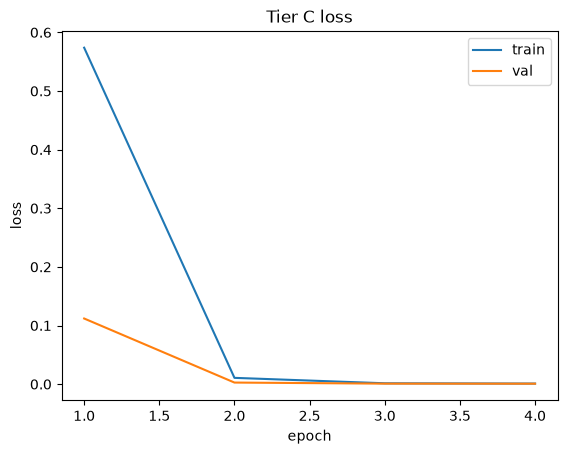

In [12]:
import matplotlib.pyplot as plt
tr = hist.dropna(subset=["loss"]); ev = hist.dropna(subset=["eval_loss"])
plt.plot(tr["epoch"], tr["loss"], label="train"); plt.plot(ev["epoch"], ev["eval_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Tier C loss")
plt.savefig("results_tierc_loss.png", dpi=120); plt.show()

## Binary framings (same split, remapped labels)
Running human-vs-styled and neutral-vs-styled.

In [13]:
def remap(df, mapping):
    d = df.copy(); d["class_id"] = d["class_id"].map(mapping)
    return d[d["class_id"] >= 0].reset_index(drop=True)

In [14]:
tr2 = remap(train, {0:0,1:-1,2:1}); va2 = remap(val,{0:0,1:-1,2:1}); te2 = remap(test,{0:0,1:-1,2:1})
train_tier_c(tr2, va2, te2, 2, "human_vs_styled")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3163.56it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.415320,0.013452,0.992063,0.992063
2,0.010537,0.012151,0.992063,0.992063
3,0.000509,0.000006,1.000000,1.000000
4,0.000187,0.000008,1.000000,1.000000


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned m

[Tier C · human_vs_styled] test acc=1.000 f1=1.000
[[63  0]
 [ 0 63]]


(<transformers.trainer.Trainer at 0x2c241cd3d50>,
        loss  grad_norm  learning_rate  epoch  step  eval_loss  eval_acc  \
 0  0.415320   0.152945       0.000151    1.0    37        NaN       NaN   
 1       NaN        NaN            NaN    1.0    37   0.013452  0.992063   
 2  0.010537   0.009915       0.000101    2.0    74        NaN       NaN   
 3       NaN        NaN            NaN    2.0    74   0.012151  0.992063   
 4  0.000509   0.004428       0.000051    3.0   111        NaN       NaN   
 5       NaN        NaN            NaN    3.0   111   0.000006  1.000000   
 6  0.000187   0.017470       0.000001    4.0   148        NaN       NaN   
 7       NaN        NaN            NaN    4.0   148   0.000008  1.000000   
 8       NaN        NaN            NaN    4.0   148        NaN       NaN   
 
     eval_f1  eval_runtime  eval_samples_per_second  eval_steps_per_second  \
 0       NaN           NaN                      NaN                    NaN   
 1  0.992063       28.5178      

In [15]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel
tok = AutoTokenizer.from_pretrained("roberta-base")
base = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=3)
model = PeftModel.from_pretrained(base, "models/tierC_tertiary").eval()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5651.42it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
import json, numpy as np, torch
def predict_class(text):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=256)
    return int(model(**enc).logits.argmax(1))

for probe in ["probe_modern_human", "probe_sop"]:
    rows = [json.loads(l) for l in open(f"data/dataset/{probe}.jsonl")]
    preds = [predict_class(r["text"]) for r in rows]
    print(f"{probe}: predicted classes {np.bincount(preds, minlength=3)} (0=human 1=neutral 2=styled)")

probe_modern_human: predicted classes [52  0  8] (0=human 1=neutral 2=styled)
probe_sop: predicted classes [ 0 11  0] (0=human 1=neutral 2=styled)


In [17]:
import json, torch, numpy as np
from captum.attr import LayerIntegratedGradients

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()

def fwd(input_ids, attention_mask):
    return model(input_ids=input_ids, attention_mask=attention_mask).logits

lig = LayerIntegratedGradients(fwd, model.get_input_embeddings())

def saliency(text, top_k=12):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    target = int(model(**enc).logits.argmax(1))           # predicted class (likely 1=neutral)
    ref = torch.full_like(enc["input_ids"], tok.pad_token_id)
    att = lig.attribute(inputs=enc["input_ids"], baselines=ref,
                        additional_forward_args=(enc["attention_mask"],),
                        target=target, n_steps=32)
    scores = att.sum(-1).squeeze(0).detach().cpu().numpy()
    toks = tok.convert_ids_to_tokens(enc["input_ids"].squeeze(0))
    pairs = [(t, s) for t, s in zip(toks, scores) if t not in ("[CLS]","[SEP]","[PAD]")]
    top = sorted(pairs, key=lambda x: -x[1])[:top_k]      # most AI-pushing tokens
    print(f"predicted class {target} (0=human 1=neutral 2=styled)")
    print("top AI-signaling tokens:", [t for t, _ in top])
    return top

sop = [json.loads(l) for l in open("data/dataset/probe_sop.jsonl")]
for r in sop[:3]:
    print("="*60)
    print(r["text"][:150], "...")
    saliency(r["text"])

There are some labs you discover and think, “this is interesting.” And then there are a few rare
ones that make you feel, almost immediately, “this is ...
predicted class 1 (0=human 1=neutral 2=styled)
top AI-signaling tokens: ['Ġspace', 'Ġyou', 'Ġthe', 'Ġyou', 'Ġpeople', 'Ġkind', '</s>', 'Ġexc', ',', 'ĠAI', 'ones', 'Ġacross']
Over time, I have realized that this is the kind of researcher I want to become. I enjoy building
AI systems, but even more than that, I am fascinated ...
predicted class 1 (0=human 1=neutral 2=styled)
top AI-signaling tokens: ['Ġto', 'Ġlike', 'Ġresearcher', 'Ġsystems', 'Ġwant', 'AI', 'Over', 'Ġa', 'Ġwant', 'Ġmeasured', 'ĠAI', 'Ġthey']
A major reason for this excitement is Prof. Ponnurangam Kumaraguru. From everything I have
seen, PK sir feels like a larger-than-life figure in Indian ...
predicted class 1 (0=human 1=neutral 2=styled)
top AI-signaling tokens: ['Ċ', '.', '.', 'Ġmajor', '</s>', 'ĠAI', 'Ġwant', 'Ġsystems', 'Ġreson', 'Ġresponsible', 'ates', 'Ġscale']


## Same but for distilbert-base-uncased

In [33]:
DATA = Path("data/dataset"); MODEL = "distilbert-base-uncased"
def load_jsonl(p): return [json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
train, val, test = (pd.DataFrame(load_jsonl(DATA/f"{s}.jsonl")) for s in ("train","val","test"))

In [34]:
tok = AutoTokenizer.from_pretrained(MODEL)
def to_ds(df, label_col="class_id"):
    d = Dataset.from_pandas(df[["text", label_col]].rename(columns={label_col: "labels"}))
    return d.map(lambda b: tok(b["text"], truncation=True, max_length=256), batched=True)

In [35]:
def build_lora_model(n_labels):
    base = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=n_labels)
    cfg = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
                     target_modules=["q_lin", "v_lin"])
    m = get_peft_model(base, cfg)
    m.print_trainable_parameters()
    return m

In [36]:
def metrics(eval_pred):
    logits, labels = eval_pred
    p = np.argmax(logits, axis=1)
    return {"acc": accuracy_score(labels, p), "f1": f1_score(labels, p, average="macro")}

In [37]:
def train_tier_c(train_df, val_df, test_df, n_labels, tag):
    dtr, dva, dte = to_ds(train_df), to_ds(val_df), to_ds(test_df)
    model = build_lora_model(n_labels)
    args = TrainingArguments(output_dir=f"tierC_{tag}", num_train_epochs=4,
                             per_device_train_batch_size=16, per_device_eval_batch_size=32,
                             eval_strategy="epoch", logging_strategy="epoch",
                             save_strategy="epoch", load_best_model_at_end=True,
                             metric_for_best_model="f1", learning_rate=2e-4, report_to="none")
    trainer = Trainer(model=model, args=args, train_dataset=dtr, eval_dataset=dva,
                      data_collator=DataCollatorWithPadding(tok), compute_metrics=metrics)
    trainer.train()
    preds = trainer.predict(dte)
    p = np.argmax(preds.predictions, axis=1)
    print(f"[Tier C · {tag}] test acc={accuracy_score(dte['labels'],p):.3f} "
          f"f1={f1_score(dte['labels'],p,average='macro'):.3f}")
    print(confusion_matrix(dte["labels"], p))
    # loss curve
    hist = pd.DataFrame(trainer.state.log_history)
    model.save_pretrained(f"models/tierC_{tag}")
    return trainer, hist, p

In [38]:
trainer, hist, preds = train_tier_c(train, val, test, 3, "tertiary")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7397.88it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.293676,0.011192,1.000000,1.000000
2,0.009323,0.002609,1.000000,1.000000
3,0.004627,0.002188,1.000000,1.000000
4,0.003311,0.001580,1.000000,1.000000


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\peft\utils\other.py:1419: UserWarning: Unable to fetch remote file due to the following error [Errno 11001] getaddrinfo failed - silently ignoring the lookup for the file config.json in distilbert-base-uncased.
  warnings.warn(
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\peft\utils\save_and_load.py:372: UserWarning: Could not find a config file in distilbert-base-uncased - will assume that the vocabulary was not modified.
  warnings.warn(
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerat

[Tier C · tertiary] test acc=1.000 f1=1.000
[[63  0  0]
 [ 0 63  0]
 [ 0  0 63]]


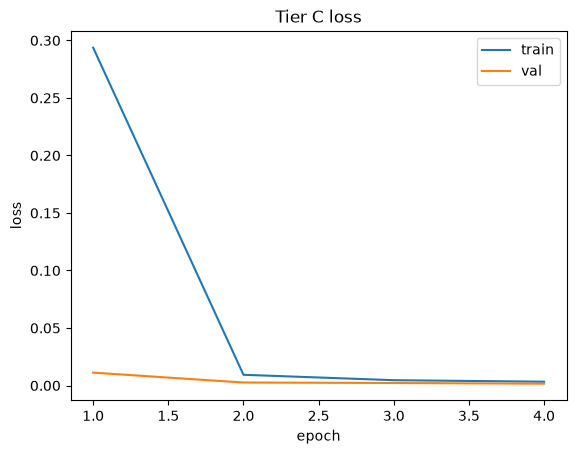

In [39]:
import matplotlib.pyplot as plt
tr = hist.dropna(subset=["loss"]); ev = hist.dropna(subset=["eval_loss"])
plt.plot(tr["epoch"], tr["loss"], label="train"); plt.plot(ev["epoch"], ev["eval_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Tier C loss")
plt.savefig("results_tierc_loss.png", dpi=120); plt.show()

In [40]:
def remap(df, mapping):
    d = df.copy(); d["class_id"] = d["class_id"].map(mapping)
    return d[d["class_id"] >= 0].reset_index(drop=True)

In [41]:
tr2 = remap(train, {0:0,1:-1,2:1}); va2 = remap(val,{0:0,1:-1,2:1}); te2 = remap(test,{0:0,1:-1,2:1})
train_tier_c(tr2, va2, te2, 2, "human_vs_styled")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4760.79it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.247191,0.005180,1.000000,1.000000
2,0.005212,0.002115,1.000000,1.000000
3,0.004586,0.000304,1.000000,1.000000
4,0.005422,0.000282,1.000000,1.000000


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned m

[Tier C · human_vs_styled] test acc=1.000 f1=1.000
[[63  0]
 [ 0 63]]


(<transformers.trainer.Trainer at 0x2c241d37e50>,
        loss  grad_norm  learning_rate  epoch  step  eval_loss  eval_acc  \
 0  0.247191   0.072638       0.000151    1.0    37        NaN       NaN   
 1       NaN        NaN            NaN    1.0    37   0.005180       1.0   
 2  0.005212   0.285846       0.000101    2.0    74        NaN       NaN   
 3       NaN        NaN            NaN    2.0    74   0.002115       1.0   
 4  0.004586   0.002608       0.000051    3.0   111        NaN       NaN   
 5       NaN        NaN            NaN    3.0   111   0.000304       1.0   
 6  0.005422   0.034933       0.000001    4.0   148        NaN       NaN   
 7       NaN        NaN            NaN    4.0   148   0.000282       1.0   
 8       NaN        NaN            NaN    4.0   148        NaN       NaN   
 
    eval_f1  eval_runtime  eval_samples_per_second  eval_steps_per_second  \
 0      NaN           NaN                      NaN                    NaN   
 1      1.0       14.0410         

In [43]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel
tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
base = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=3)
model = PeftModel.from_pretrained(base, "models/tierC_tertiary").eval()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3009.73it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ValueError: No modules were targeted for adaptation. This might be caused by a combination of mismatched target modules and excluded modules. Please check your `target_modules` and `exclude_modules` configuration. You may also have only targeted modules that are marked to be saved (`modules_to_save`).

In [44]:
import json, numpy as np, torch
def predict_class(text):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=256)
    return int(model(**enc).logits.argmax(1))

for probe in ["probe_modern_human", "probe_sop"]:
    rows = [json.loads(l) for l in open(f"data/dataset/{probe}.jsonl")]
    preds = [predict_class(r["text"]) for r in rows]
    print(f"{probe}: predicted classes {np.bincount(preds, minlength=3)} (0=human 1=neutral 2=styled)")

probe_modern_human: predicted classes [ 1 59  0] (0=human 1=neutral 2=styled)
probe_sop: predicted classes [ 1 10  0] (0=human 1=neutral 2=styled)


In [45]:
import json, torch, numpy as np
from captum.attr import LayerIntegratedGradients

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()

def fwd(input_ids, attention_mask):
    return model(input_ids=input_ids, attention_mask=attention_mask).logits

lig = LayerIntegratedGradients(fwd, model.get_input_embeddings())

def saliency(text, top_k=12):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    target = int(model(**enc).logits.argmax(1))           # predicted class (likely 1=neutral)
    ref = torch.full_like(enc["input_ids"], tok.pad_token_id)
    att = lig.attribute(inputs=enc["input_ids"], baselines=ref,
                        additional_forward_args=(enc["attention_mask"],),
                        target=target, n_steps=32)
    scores = att.sum(-1).squeeze(0).detach().cpu().numpy()
    toks = tok.convert_ids_to_tokens(enc["input_ids"].squeeze(0))
    pairs = [(t, s) for t, s in zip(toks, scores) if t not in ("[CLS]","[SEP]","[PAD]")]
    top = sorted(pairs, key=lambda x: -x[1])[:top_k]      # most AI-pushing tokens
    print(f"predicted class {target} (0=human 1=neutral 2=styled)")
    print("top AI-signaling tokens:", [t for t, _ in top])
    return top

sop = [json.loads(l) for l in open("data/dataset/probe_sop.jsonl")]
for r in sop[:3]:
    print("="*60)
    print(r["text"][:150], "...")
    saliency(r["text"])

There are some labs you discover and think, “this is interesting.” And then there are a few rare
ones that make you feel, almost immediately, “this is ...
predicted class 1 (0=human 1=neutral 2=styled)
top AI-signaling tokens: ['about', 'are', ',', 'are', 'this', 'responsible', 'what', '##able', 'research', 'understand', 'are', 'of']
Over time, I have realized that this is the kind of researcher I want to become. I enjoy building
AI systems, but even more than that, I am fascinated ...
predicted class 1 (0=human 1=neutral 2=styled)
top AI-signaling tokens: ['want', 'on', 'on', 'that', 'on', 'that', 'that', 'want', 'for', 'that', 'can', 'this']
A major reason for this excitement is Prof. Ponnurangam Kumaraguru. From everything I have
seen, PK sir feels like a larger-than-life figure in Indian ...
predicted class 1 (0=human 1=neutral 2=styled)
top AI-signaling tokens: ['seen', '##ly', 'to', 'what', 'have', 'responsible', 'reflect', '.', 'as', '##l', 'managed', 'ai']
